In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# 1. Load and Clean Dataset
# ============================================================
try:
    df = pd.read_csv("final_similarity_results.csv")
except FileNotFoundError:
    print("Error: 'final_similarity_results.csv' not found.")
    df = pd.DataFrame(columns=["user_id", "assignment_id", "max_similarity_score"])

user_ids = sorted(df["user_id"].unique())
id_map = {uid: i + 1 for i, uid in enumerate(user_ids)}
df["user_id"] = df["user_id"].map(id_map)

# Data Cleaning: semester and assignment number extraction
df["semester"] = df["assignment_id"].str.extract(r"([a-z]\d+)")
df["assignment_number"] = pd.to_numeric(
    df["assignment_id"].str.extract(r"a(\d+)")[0], errors="coerce"
)
df["assignment_label"] = df["assignment_id"].str.extract(r"(a\d+)")

In [ ]:
# ============================================================
# 2. Global & Distribution Statistics
# ============================================================
print("--- Global Statistics ---")
print(df["max_similarity_score"].describe())
print(f"Skewness: {df['max_similarity_score'].skew():.2f}")
print(f"Kurtosis: {df['max_similarity_score'].kurt():.2f}")

# Cross-semester assignment coverage check
# f24, 70 students
# s25, 111 students
print("\n--- Assignment Coverage by Semester ---")
print(df.groupby(["semester", "assignment_number"]).size().unstack(fill_value=0))

--- Global Statistics ---
count    646.000000
mean       0.577107
std        0.080085
min        0.377930
25%        0.522949
50%        0.566162
75%        0.625854
max        0.846191
Name: max_similarity_score, dtype: float64
Skewness: 0.46
Kurtosis: 0.12

--- Assignment Coverage by Semester ---
assignment_number   2   3   4   5   6   7
semester                                 
f24                39  57  50  46  44  52
s25                62  74  64  54  56  48


In [31]:
# ============================================================
# 3. Assignment-Level Analysis (with Constraint Analysis)
# ============================================================
assignment_stats = (
    df.groupby("assignment_id")["max_similarity_score"]
    .agg(["mean", "median", "std", "min", "max", "count"])
)
assignment_stats["CV"] = assignment_stats["std"] / assignment_stats["mean"]

print("\n--- Assignment-Level Statistics (Sorted by mean) ---")
print(assignment_stats.sort_values(by="mean", ascending=False))


--- Assignment-Level Statistics (Sorted by mean) ---
                   mean    median       std       min       max  count  \
assignment_id                                                            
f24_a7         0.623066  0.627930  0.077556  0.492188  0.809082     52   
s25_a7         0.607264  0.603760  0.065486  0.480469  0.752441     48   
s25_a2         0.600779  0.567139  0.083655  0.496338  0.785645     62   
f24_a6         0.593772  0.567383  0.085934  0.435547  0.773926     44   
s25_a6         0.590611  0.582764  0.079108  0.382812  0.790527     56   
f24_a4         0.584297  0.594238  0.057947  0.484863  0.767578     50   
s25_a5         0.583415  0.574951  0.068117  0.408447  0.693359     54   
s25_a4         0.577759  0.573486  0.052562  0.476562  0.698242     64   
f24_a2         0.576353  0.554688  0.081100  0.449463  0.801270     39   
f24_a5         0.571337  0.567871  0.063741  0.437500  0.732422     46   
s25_a3         0.538822  0.511230  0.093941  0.387695  0.8

In [32]:
# ============================================================
# 4. Student-Level Analysis (Performance, Volatility & Risk)
# ============================================================
HIGH_THRESHOLD = 0.75
LOW_THRESHOLD  = 0.65

student_stats = (
    df.groupby("user_id")["max_similarity_score"]
    .agg(["mean", "max", "std", "count"])
    .sort_values(by="mean", ascending=False)
)

# Rate of submissions above each threshold per student
student_stats["high_sim_rate"] = df.groupby("user_id").apply(
    lambda x: (x["max_similarity_score"] >= HIGH_THRESHOLD).mean()
)
student_stats["moderate_sim_rate"] = df.groupby("user_id").apply(
    lambda x: (x["max_similarity_score"] >= LOW_THRESHOLD).mean()
)

print("\n--- Top 5 Students by Average Similarity ---")
print(student_stats.head(5))

print("\n--- Students with High Sim Rate > 50% ---")
print(student_stats[student_stats["high_sim_rate"] > 0.5])


--- Top 5 Students by Average Similarity ---
             mean       max       std  count  high_sim_rate  moderate_sim_rate
user_id                                                                       
18       0.692383  0.692383       NaN      1       0.000000           1.000000
93       0.690918  0.801270  0.095578      3       0.333333           0.333333
85       0.684163  0.846191  0.109981      6       0.333333           0.500000
114      0.681543  0.771973  0.068137      5       0.200000           0.600000
128      0.678711  0.717773  0.037471      3       0.000000           0.666667

--- Students with High Sim Rate > 50% ---
Empty DataFrame
Columns: [mean, max, std, count, high_sim_rate, moderate_sim_rate]
Index: []


C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3029808338.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  student_stats["high_sim_rate"] = df.groupby("user_id").apply(
C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3029808338.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  student_stats["moderate_sim_rate"] = df.groupby("user_id").apply(


In [33]:
# ============================================================
# 5. Student Trajectory Analysis
# ============================================================
student_trend = (
    df.sort_values("assignment_number")
    .groupby(["user_id", "assignment_number"])["max_similarity_score"]
    .mean()
    .unstack()
)
print("\n--- Student Trajectories (first 5 students) ---")
print(student_trend.head(5))


--- Student Trajectories (first 5 students) ---
assignment_number         2         3         4         5         6         7
user_id                                                                      
1                  0.760742       NaN  0.540039  0.632324  0.624512  0.731445
2                  0.590332  0.472900  0.504395  0.516602  0.564941  0.567383
3                       NaN  0.511230       NaN       NaN  0.521973  0.575684
4                       NaN  0.571777       NaN       NaN  0.773926  0.545410
5                  0.566406       NaN  0.567383       NaN       NaN       NaN


In [ ]:
# ============================================================
# 6. Threshold & Semester Trends
# ============================================================
for label, threshold in [("High (>=0.75)", HIGH_THRESHOLD), ("Moderate (>=0.65)", LOW_THRESHOLD)]:
    count = len(df[df["max_similarity_score"] >= threshold])
    print(f"\nSubmissions {label}: {count} ({round(count / len(df) * 100, 2)}%)")

semester_comparison = df.groupby("semester")["max_similarity_score"].agg(["mean", "std"])
print("\n--- Semester Comparison ---")
print(semester_comparison)


Submissions High (>=0.75): 21 (3.25%)

Submissions Moderate (>=0.65): 115 (17.8%)

--- Semester Comparison ---
              mean       std
semester                    
f24       0.572868  0.081269
s25       0.580517  0.079068


C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3856624744.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3856624744.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


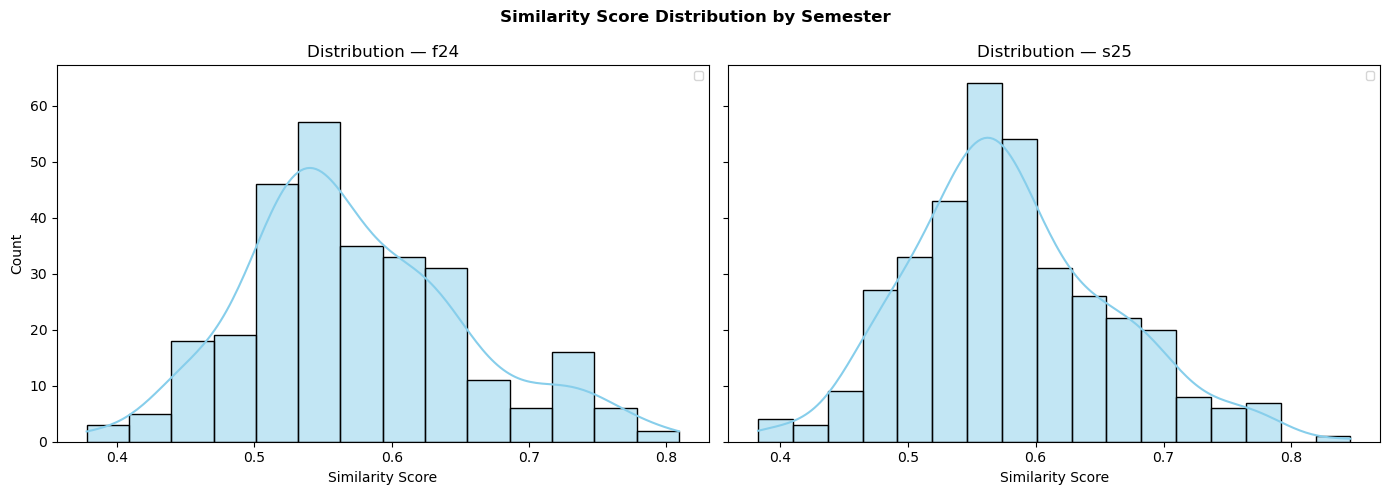

In [53]:
# ============================================================
# 7. Enhanced Visualizations
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (semester, group) in zip(axes, df.groupby("semester")):
    sns.histplot(group["max_similarity_score"], kde=True, ax=ax, color="skyblue")
    ax.set_title(f"Distribution — {semester}")
    ax.set_xlabel("Similarity Score")
    ax.legend(fontsize=8)

plt.suptitle("Similarity Score Distribution by Semester", fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\1653793525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="semester", y="max_similarity_score", data=df, palette="Set2")


Text(0.5, 1.0, "Score Spread: Fall '24 vs Spring '25")

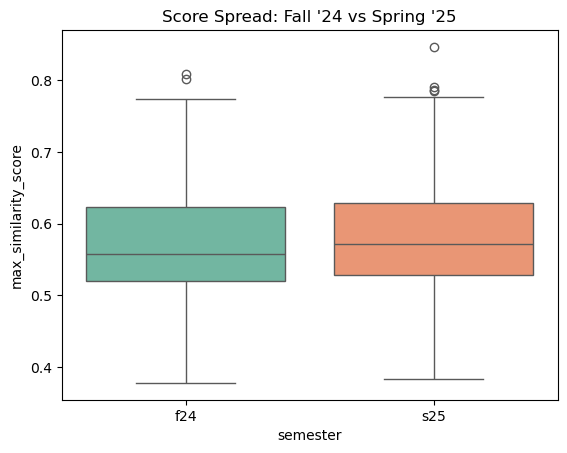

In [44]:
# Plot 2: Boxplot by Semester
plt.figure()
sns.boxplot(x="semester", y="max_similarity_score", data=df, palette="Set2")
plt.title("Score Spread: Fall '24 vs Spring '25")

Text(0.5, 1.0, 'Temporal Trend of Similarity')

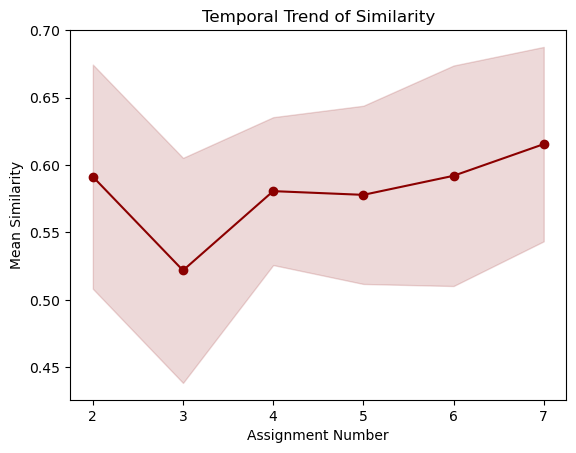

In [48]:

# Plot 3: Temporal Trend with real std band (not hardcoded ±0.05)
plt.figure()
trend_mean = df.groupby("assignment_number")["max_similarity_score"].mean()
trend_std  = df.groupby("assignment_number")["max_similarity_score"].std()
plt.plot(trend_mean.index, trend_mean.values, marker="o", linestyle="-", color="darkred")
plt.fill_between(
    trend_mean.index,
    trend_mean - trend_std,
    trend_mean + trend_std,
    alpha=0.15, color="darkred", label="±1 std"
)
plt.xlabel("Assignment Number")
plt.ylabel("Mean Similarity")
plt.title("Temporal Trend of Similarity")

Text(0.5, 1.0, 'Cumulative Distribution by Semester')

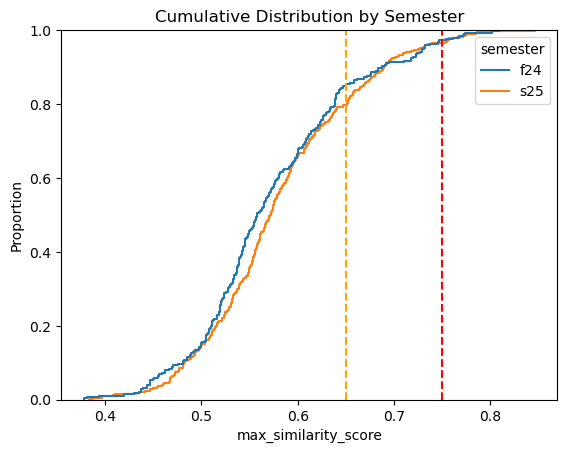

In [47]:
# Plot 4: ECDF by Semester
plt.figure()
sns.ecdfplot(data=df, x="max_similarity_score", hue="semester")
plt.axvline(HIGH_THRESHOLD, color="red",    linestyle="--", label=f"{HIGH_THRESHOLD}")
plt.axvline(LOW_THRESHOLD,  color="orange", linestyle="--", label=f"{LOW_THRESHOLD}")
plt.title("Cumulative Distribution by Semester")

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'a2'),
  Text(1, 0, 'a4'),
  Text(2, 0, 'a5'),
  Text(3, 0, 'a6'),
  Text(4, 0, 'a7'),
  Text(5, 0, 'a3')])

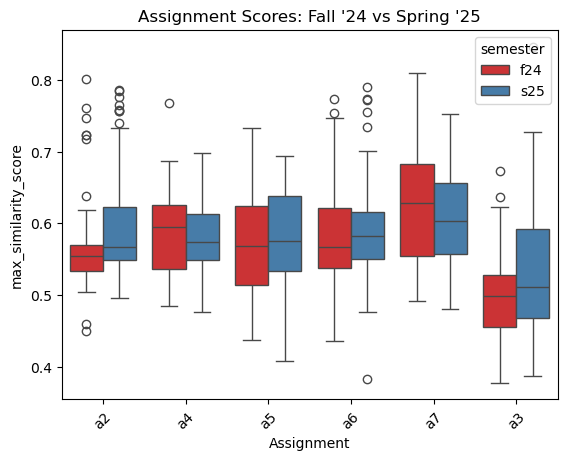

In [50]:
# Plot 5: Per-assignment boxplot grouped by semester (NEW)
plt.figure()
sns.boxplot(
    x="assignment_label", y="max_similarity_score",
    hue="semester", data=df, palette="Set1"
)
plt.title("Assignment Scores: Fall '24 vs Spring '25")
plt.xlabel("Assignment")
plt.xticks(rotation=45)

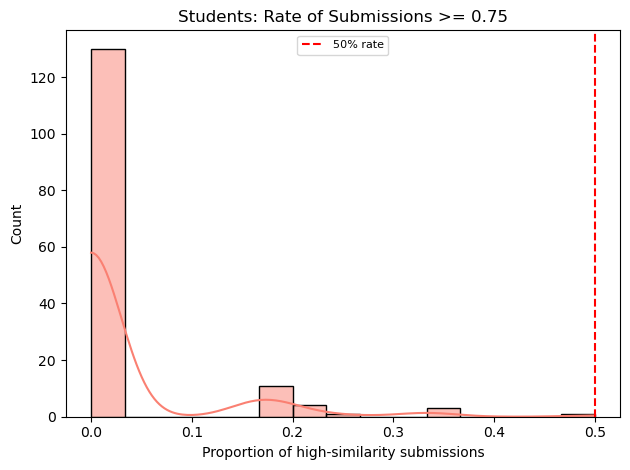

In [ ]:
# Plot 6: Student high-sim rate distribution (NEW)
plt.figure()
sns.histplot(student_stats["high_sim_rate"], bins=15, color="salmon", kde=True)
plt.axvline(0.5, color="red", linestyle="--", label="50% rate")
plt.title(f"Students: Rate of Submissions >= {HIGH_THRESHOLD}")
plt.xlabel("Proportion of high-similarity submissions")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

--- Global Statistics ---
count    646.000000
mean       0.577107
std        0.080085
min        0.377930
25%        0.522949
50%        0.566162
75%        0.625854
max        0.846191
Name: max_similarity_score, dtype: float64
Skewness: 0.46
Kurtosis: 0.12

--- Assignment-Level Statistics (Sorted by mean) ---
                   mean    median       std       min       max  count  \
assignment_id                                                            
f24_a7         0.623066  0.627930  0.077556  0.492188  0.809082     52   
s25_a7         0.607264  0.603760  0.065486  0.480469  0.752441     48   
s25_a2         0.600779  0.567139  0.083655  0.496338  0.785645     62   
f24_a6         0.593772  0.567383  0.085934  0.435547  0.773926     44   
s25_a6         0.590611  0.582764  0.079108  0.382812  0.790527     56   
f24_a4         0.584297  0.594238  0.057947  0.484863  0.767578     50   
s25_a5         0.583415  0.574951  0.068117  0.408447  0.693359     54   
s25_a4         0.5777

C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3263319938.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3263319938.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


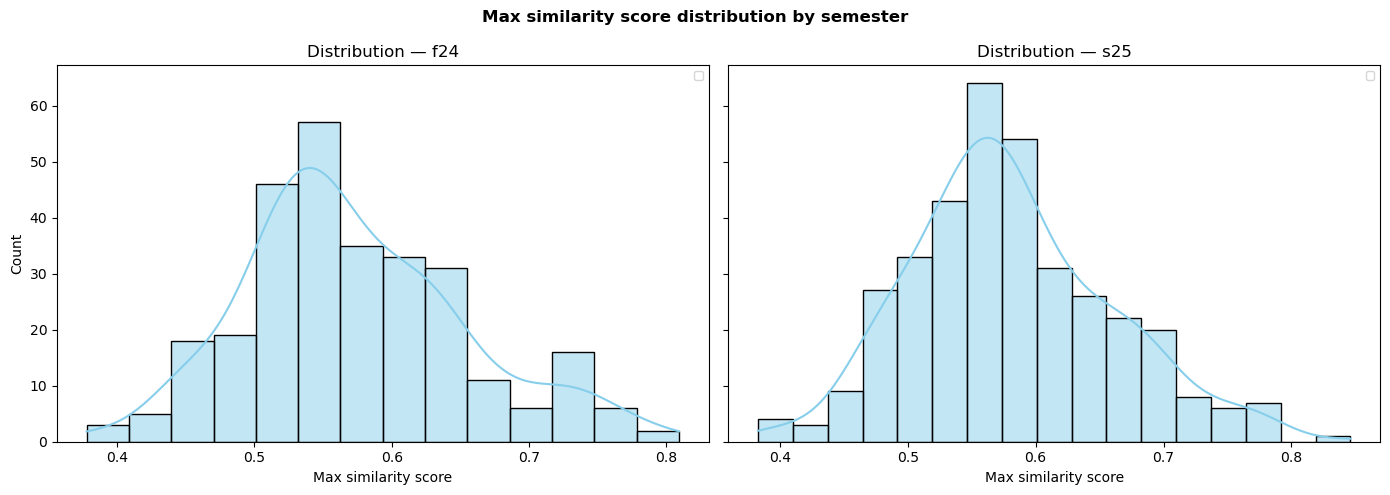

C:\Users\antoi\AppData\Local\Temp\ipykernel_67848\3263319938.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


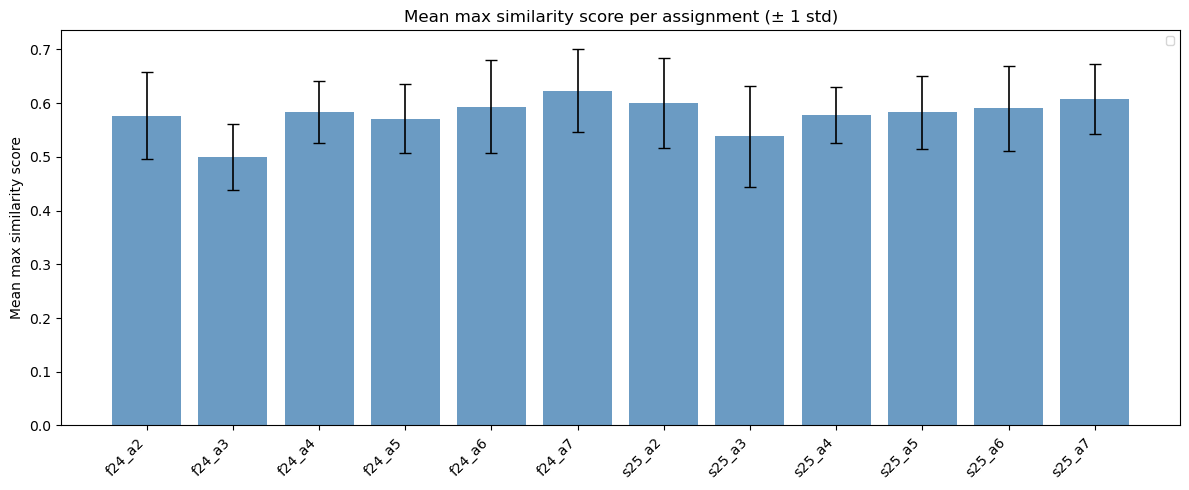

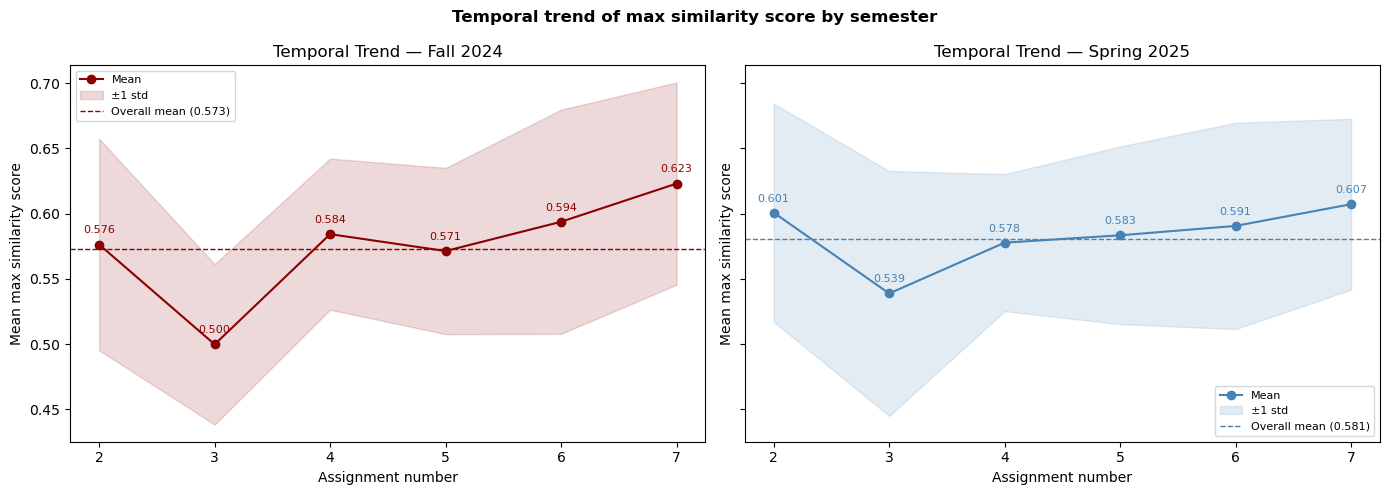

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Load and Clean Dataset
# ============================================================
try:
    df = pd.read_csv("final_similarity_results.csv")
except FileNotFoundError:
    print("Error: 'final_similarity_results.csv' not found.")
    df = pd.DataFrame(columns=["user_id", "assignment_id", "max_similarity_score"])

# Map each unique user_id to an anonymous student number
user_ids = sorted(df["user_id"].unique())
id_map = {uid: i + 1 for i, uid in enumerate(user_ids)}
df["student_id"] = df["user_id"].map(id_map)

# Semester and assignment number extraction
df["semester"] = df["assignment_id"].str.extract(r"([a-z]\d+)")
df["assignment_number"] = pd.to_numeric(
    df["assignment_id"].str.extract(r"a(\d+)")[0], errors="coerce"
)

# Thresholds
HIGH_THRESHOLD     = 0.75
MODERATE_THRESHOLD = 0.65

# ============================================================
# 2. Global Statistics
# ============================================================
print("--- Global Statistics ---")
print(df["max_similarity_score"].describe())
print(f"Skewness: {df['max_similarity_score'].skew():.2f}")
print(f"Kurtosis: {df['max_similarity_score'].kurt():.2f}")

# ============================================================
# 3. Assignment-Level Analysis
# ============================================================
assignment_stats = (
    df.groupby("assignment_id")["max_similarity_score"]
    .agg(["mean", "median", "std", "min", "max", "count"])
)
assignment_stats["CV"] = assignment_stats["std"] / assignment_stats["mean"]

print("\n--- Assignment-Level Statistics (Sorted by mean) ---")
print(assignment_stats.sort_values(by="mean", ascending=False))

# ============================================================
# 4. Semester Comparison
# ============================================================
for label, threshold in [("High (>=0.75)", HIGH_THRESHOLD), ("Moderate (>=0.65)", MODERATE_THRESHOLD)]:
    count = len(df[df["max_similarity_score"] >= threshold])
    print(f"\nSubmissions {label}: {count} ({round(count / len(df) * 100, 2)}%)")

semester_comparison = df.groupby("semester")["max_similarity_score"].agg(["mean", "std"])
print("\n--- Semester Comparison ---")
print(semester_comparison)

# ============================================================
# 5. Visualizations
# ============================================================

# Plot 1: Distribution per semester (side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (semester, group) in zip(axes, df.groupby("semester")):
    sns.histplot(group["max_similarity_score"], kde=True, ax=ax, color="skyblue")
    ax.set_title(f"Distribution — {semester}")
    ax.set_xlabel("Max similarity score")
    ax.legend(fontsize=8)
plt.suptitle("Max similarity score distribution by semester", fontweight="bold")
plt.tight_layout()
plt.show()

# Plot 2: Assignment-level statistics (mean ± std bar chart)
assignment_stats_sorted = assignment_stats.sort_values("assignment_id")
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(assignment_stats_sorted))
bars = ax.bar(
    x, assignment_stats_sorted["mean"],
    yerr=assignment_stats_sorted["std"],
    capsize=4, color="steelblue", alpha=0.8, error_kw={"elinewidth": 1.2}
)
ax.set_xticks(x)
ax.set_xticklabels(assignment_stats_sorted.index, rotation=45, ha="right")
ax.set_ylabel("Mean max similarity score")
ax.set_title("Mean max similarity score per assignment (± 1 std)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plot 3: Temporal trend per semester (side by side)
semesters  = sorted(df["semester"].unique())
colors     = {"f24": "darkred", "s25": "steelblue"}
sem_labels = {"f24": "Fall 2024", "s25": "Spring 2025"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, semester in zip(axes, semesters):
    subset       = df[df["semester"] == semester]
    trend_mean   = subset.groupby("assignment_number")["max_similarity_score"].mean()
    trend_std    = subset.groupby("assignment_number")["max_similarity_score"].std()
    global_mean  = subset["max_similarity_score"].mean()
    color        = colors.get(semester, "gray")

    ax.plot(trend_mean.index, trend_mean.values, marker="o", color=color, label="Mean")
    ax.fill_between(
        trend_mean.index,
        trend_mean - trend_std,
        trend_mean + trend_std,
        alpha=0.15, color=color, label="±1 std"
    )
    ax.axhline(global_mean, color=color, linestyle="--", linewidth=1, label=f"Overall mean ({global_mean:.3f})")

    # Annotate each point with its mean value
    for x, y in trend_mean.items():
        ax.annotate(f"{y:.3f}", xy=(x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8, color=color)

    ax.set_title(f"Temporal Trend — {sem_labels.get(semester, semester)}")
    ax.set_xlabel("Assignment number")
    ax.set_ylabel("Mean max similarity score")
    ax.set_xticks(trend_mean.index)
    ax.legend(fontsize=8)

plt.suptitle("Temporal trend of max similarity score by semester", fontweight="bold")
plt.tight_layout()
plt.show()
